In [1]:
!pip install pyspark -q

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("DEM_Milestone3") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Spark Started")

Spark Started


In [8]:
import zipfile
import os

zip_path = "/content/ingestion_layer.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/extracted")

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [9]:
import os

parquet_files = []

for root, dirs, files in os.walk("/content/extracted"):
    for file in files:
        if file.endswith(".parquet"):
            parquet_files.append(os.path.join(root, file))

print("Number of parquet files:", len(parquet_files))
print("\nFirst few files:")

for p in parquet_files[:5]:
    print(p)

Number of parquet files: 192

First few files:
/content/extracted/ingestion_layer/partitioned_data/year=2024/month=4/part-00002-a89b91bc-951d-4be0-a71a-876c2ab03c30.c000.snappy.parquet
/content/extracted/ingestion_layer/partitioned_data/year=2024/month=4/part-00005-a89b91bc-951d-4be0-a71a-876c2ab03c30.c000.snappy.parquet
/content/extracted/ingestion_layer/partitioned_data/year=2024/month=4/part-00001-a89b91bc-951d-4be0-a71a-876c2ab03c30.c000.snappy.parquet
/content/extracted/ingestion_layer/partitioned_data/year=2024/month=4/part-00004-a89b91bc-951d-4be0-a71a-876c2ab03c30.c000.snappy.parquet
/content/extracted/ingestion_layer/partitioned_data/year=2024/month=4/part-00003-a89b91bc-951d-4be0-a71a-876c2ab03c30.c000.snappy.parquet


In [10]:
df = spark.read.parquet(*parquet_files)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [11]:
print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 8844800
Columns: 20


In [12]:
df.printSchema()

root
 |-- station_id: string (nullable = true)
 |-- state: string (nullable = true)
 |-- city: string (nullable = true)
 |-- station_name: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- datetime: date (nullable = true)
 |-- at_c: double (nullable = true)
 |-- rh_percent: double (nullable = true)
 |-- ws_m_s: double (nullable = true)
 |-- wd_deg: double (nullable = true)
 |-- rf_mm: double (nullable = true)
 |-- tot_rf_mm: double (nullable = true)
 |-- sr_w_mt2: double (nullable = true)
 |-- bp_mmhg: double (nullable = true)
 |-- vws_m_s: double (nullable = true)
 |-- pollutant: string (nullable = true)
 |-- value: double (nullable = true)
 |-- station: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- hour: integer (nullable = true)



In [13]:
df.show(5, truncate=False)

+----------+-----+-----+-----------------------------+-------------------------------+----------+----+----------+------+------+-----+---------+--------+-------+-------+---------+------+-----------------------------+---+----+
|station_id|state|city |station_name                 |timestamp                      |datetime  |at_c|rh_percent|ws_m_s|wd_deg|rf_mm|tot_rf_mm|sr_w_mt2|bp_mmhg|vws_m_s|pollutant|value |station                      |day|hour|
+----------+-----+-----+-----------------------------+-------------------------------+----------+----+----------+------+------+-----+---------+--------+-------+-------+---------+------+-----------------------------+---+----+
|site_1427 |Delhi|Delhi|Najafgarh, Delhi - DPCC      |2024-03-01T00:00:00.000000+0000|2024-03-01|14.0|78.0      |0.4   |210.0 |0.0  |0.0      |3.0     |994.0  |NULL   |pm10     |178.0 |Najafgarh, Delhi - DPCC      |1  |0   |
|site_105  |Delhi|Delhi|North Campus, DU, Delhi - IMD|2024-03-01T00:15:00.000000+0000|2024-03-01|NUL

In [14]:
from pyspark.sql.functions import col, when, count

missing = df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in df.columns
])

missing.show(truncate=False)

+----------+-----+----+------------+---------+--------+-------+----------+-------+-------+-------+---------+--------+-------+-------+---------+-----+-------+---+----+
|station_id|state|city|station_name|timestamp|datetime|at_c   |rh_percent|ws_m_s |wd_deg |rf_mm  |tot_rf_mm|sr_w_mt2|bp_mmhg|vws_m_s|pollutant|value|station|day|hour|
+----------+-----+----+------------+---------+--------+-------+----------+-------+-------+-------+---------+--------+-------+-------+---------+-----+-------+---+----+
|0         |0    |0   |0           |0        |0       |2532923|1519086   |1531562|1836378|4006105|801929   |1610725 |3022601|6546511|0        |0    |0      |0  |0   |
+----------+-----+----+------------+---------+--------+-------+----------+-------+-------+-------+---------+--------+-------+-------+---------+-----+-------+---+----+



In [15]:
total_rows = df.count()

unique_rows = df.dropDuplicates().count()

print("Total Rows:", total_rows)
print("Unique Rows:", unique_rows)
print("Duplicates:", total_rows - unique_rows)

Total Rows: 8844800
Unique Rows: 8844800
Duplicates: 0


In [16]:
df.describe().show(truncate=False)

+-------+----------+-------+-------+--------------------------------------+-------------------------------+-----------------+------------------+------------------+-----------------+--------------------+-------------------+------------------+-----------------+--------------------+---------+-----------------+--------------------------------------+------------------+------------------+
|summary|station_id|state  |city   |station_name                          |timestamp                      |at_c             |rh_percent        |ws_m_s            |wd_deg           |rf_mm               |tot_rf_mm          |sr_w_mt2          |bp_mmhg          |vws_m_s             |pollutant|value            |station                               |day               |hour              |
+-------+----------+-------+-------+--------------------------------------+-------------------------------+-----------------+------------------+------------------+-----------------+--------------------+-------------------+------

In [17]:
from pyspark.sql.functions import col

numeric_cols = [
    "at_c",
    "rh_percent",
    "ws_m_s",
    "wd_deg",
    "tot_rf_mm",
    "sr_w_mt2",
    "bp_mmhg"
]

medians = {}

for c in numeric_cols:
    medians[c] = df.approxQuantile(c, [0.5], 0.01)[0]

print(medians)

{'at_c': 27.1, 'rh_percent': 65.0, 'ws_m_s': 0.6, 'wd_deg': 189.0, 'tot_rf_mm': 0.0, 'sr_w_mt2': 17.0, 'bp_mmhg': 983.0}


In [18]:
clean_df = df

for c in numeric_cols:
    clean_df = clean_df.fillna(
        medians[c],
        subset=[c]
    )

clean_df = clean_df.fillna(
    0,
    subset=["rf_mm"]
)

In [19]:
from pyspark.sql.functions import count, when

missing_after = clean_df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in clean_df.columns
])

missing_after.show(truncate=False)

+----------+-----+----+------------+---------+--------+----+----------+------+------+-----+---------+--------+-------+-------+---------+-----+-------+---+----+
|station_id|state|city|station_name|timestamp|datetime|at_c|rh_percent|ws_m_s|wd_deg|rf_mm|tot_rf_mm|sr_w_mt2|bp_mmhg|vws_m_s|pollutant|value|station|day|hour|
+----------+-----+----+------------+---------+--------+----+----------+------+------+-----+---------+--------+-------+-------+---------+-----+-------+---+----+
|0         |0    |0   |0           |0        |0       |0   |0         |0     |0     |0    |0        |0       |0      |6546511|0        |0    |0      |0  |0   |
+----------+-----+----+------------+---------+--------+----+----------+------+------+-----+---------+--------+-------+-------+---------+-----+-------+---+----+



In [20]:
from pyspark.sql.functions import when

clean_df = clean_df.withColumn(
    "aqi_category",
    when(col("value") <= 50, "Good")
    .when(col("value") <= 100, "Moderate")
    .when(col("value") <= 200, "Poor")
    .otherwise("Severe")
)

In [21]:
from pyspark.sql.functions import month

clean_df = clean_df.withColumn(
    "month",
    month(col("datetime"))
)

In [22]:
from pyspark.sql.functions import when

clean_df = clean_df.withColumn(
    "season",
    when(col("month").isin([12,1,2]), "Winter")
    .when(col("month").isin([3,4,5]), "Summer")
    .when(col("month").isin([6,7,8,9]), "Monsoon")
    .otherwise("Post-Monsoon")
)

In [24]:
from pyspark.sql.functions import year, month

clean_df = clean_df.withColumn(
    "year",
    year("datetime")
)

clean_df = clean_df.withColumn(
    "month",
    month("datetime")
)

clean_df.select(
    "datetime",
    "year",
    "month"
).show(5)

+----------+----+-----+
|  datetime|year|month|
+----------+----+-----+
|2024-03-01|2024|    3|
|2024-03-01|2024|    3|
|2024-03-01|2024|    3|
|2024-03-01|2024|    3|
|2024-03-01|2024|    3|
+----------+----+-----+
only showing top 5 rows


In [25]:
clean_df.write \
    .mode("overwrite") \
    .partitionBy("year", "month") \
    .parquet("/content/cleaned_data")

In [26]:
print(clean_df.columns)

['station_id', 'state', 'city', 'station_name', 'timestamp', 'datetime', 'at_c', 'rh_percent', 'ws_m_s', 'wd_deg', 'rf_mm', 'tot_rf_mm', 'sr_w_mt2', 'bp_mmhg', 'vws_m_s', 'pollutant', 'value', 'station', 'day', 'hour', 'aqi_category', 'month', 'season', 'year']


## Before vs After Data Quality Report

In [27]:
from pyspark.sql.functions import col, when, count
import pandas as pd

# Before cleaning counts (from profiling)
before_missing = {
    "at_c":2532923,
    "rh_percent":1519086,
    "ws_m_s":1531562,
    "wd_deg":1836378,
    "rf_mm":4006105,
    "tot_rf_mm":801929,
    "sr_w_mt2":1610725,
    "bp_mmhg":3022601,
    "vws_m_s":6546511
}

# After cleaning counts
after_missing = clean_df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in before_missing.keys()
]).toPandas()

report_data = []

for column in before_missing:
    report_data.append([
        column,
        before_missing[column],
        int(after_missing[column][0])
    ])

quality_report = pd.DataFrame(
    report_data,
    columns=[
        "Column",
        "Missing_Before",
        "Missing_After"
    ]
)

quality_report

,Column,Missing_Before,Missing_After
0,at_c,2532923,0
1,rh_percent,1519086,0
2,ws_m_s,1531562,0
3,wd_deg,1836378,0
4,rf_mm,4006105,0
5,tot_rf_mm,801929,0
6,sr_w_mt2,1610725,0
7,bp_mmhg,3022601,0
8,vws_m_s,6546511,6546511


In [28]:
quality_report.to_csv(
    "before_after_quality_report.csv",
    index=False
)

print("Report Saved Successfully")

Report Saved Successfully


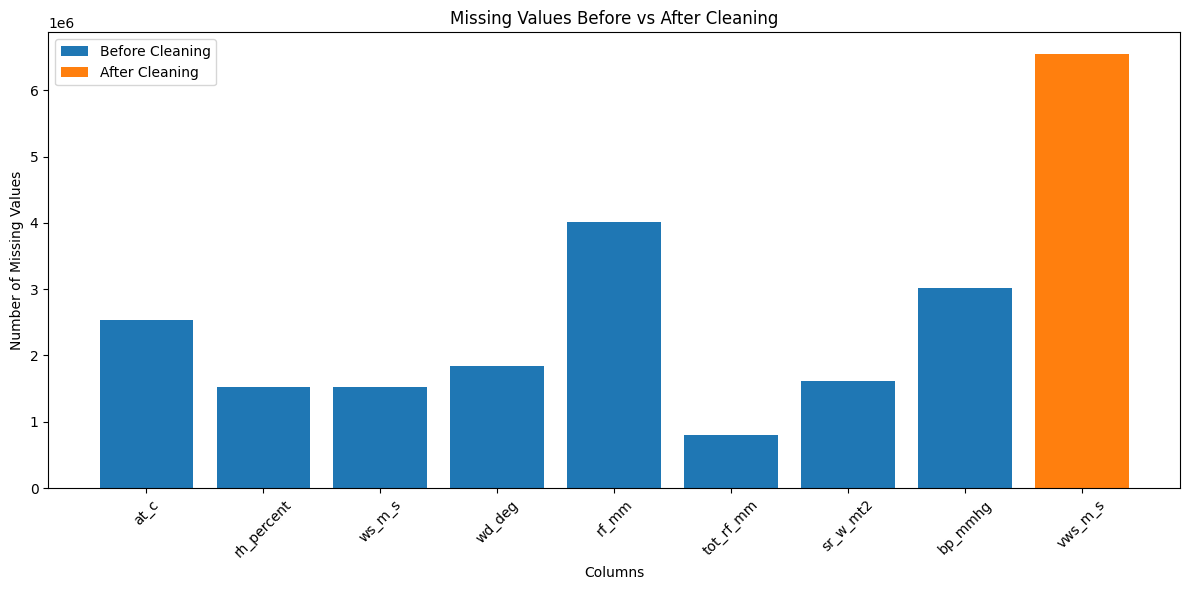

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

x = quality_report["Column"]

plt.bar(
    x,
    quality_report["Missing_Before"],
    label="Before Cleaning"
)

plt.bar(
    x,
    quality_report["Missing_After"],
    label="After Cleaning"
)

plt.title("Missing Values Before vs After Cleaning")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
summary = pd.DataFrame({
    "Metric":[
        "Total Rows",
        "Total Columns",
        "Duplicate Rows Before",
        "Duplicate Rows After"
    ],
    "Value":[
        8844800,
        20,
        0,
        0
    ]
})

summary

,Metric,Value
0,Total Rows,8844800
1,Total Columns,20
2,Duplicate Rows Before,0
3,Duplicate Rows After,0


##  Data Model Justification

In [31]:
from pyspark.sql.functions import countDistinct

dataset_stats = {
    "Total Rows": df.count(),
    "Total Columns": len(df.columns),
    "Stations": df.select("station_id").distinct().count(),
    "Pollutants": df.select("pollutant").distinct().count(),
    "States": df.select("state").distinct().count(),
    "Cities": df.select("city").distinct().count()
}

for k,v in dataset_stats.items():
    print(f"{k}: {v:,}")

Total Rows: 8,844,800
Total Columns: 20
Stations: 15
Pollutants: 13
States: 1
Cities: 1


In [32]:
print("Distinct Stations:",
      df.select("station_name").distinct().count())

print("Distinct Pollutants:",
      df.select("pollutant").distinct().count())

print("Total Records:",
      df.count())

Distinct Stations: 15
Distinct Pollutants: 13
Total Records: 8844800


Observation:

The dataset contains 8.84 million records but only a small number of
distinct stations and pollutants.

Storing station and pollutant information repeatedly in a single flat
table introduces significant redundancy.

A dimensional model reduces redundancy by separating descriptive
attributes into dimension tables and storing measurements in a fact table.

In [33]:
clean_df.groupBy(
    "station_name"
).avg(
    "value"
).show(10)

+--------------------+------------------+
|        station_name|        avg(value)|
+--------------------+------------------+
|Nehru Nagar, Delh...| 50.47873989617543|
|Punjabi Bagh, Del...| 57.26361095560805|
|Okhla Phase-2, De...| 53.65456804252076|
|Patparganj, Delhi...| 49.79129031144355|
|Jawaharlal Nehru ...| 48.84106594691416|
|Lodhi Road, Delhi...| 40.68149177720734|
|Mandir Marg, Delh...|   52.166679307636|
|Lodhi Road, Delhi...|61.621114670028696|
|Najafgarh, Delhi ...| 37.92442731720875|
|   Pusa, Delhi - IMD|58.665460366976106|
+--------------------+------------------+
only showing top 10 rows


In [34]:
clean_df.groupBy(
    "pollutant"
).avg(
    "value"
).show()

+-----------+--------------------+
|  pollutant|          avg(value)|
+-----------+--------------------+
|        so2|  12.928257846121193|
|     xylene|0.003200576205161505|
|       pm25|    96.4048486440477|
|         no|  30.183804435585145|
|  mp_xylene|  2.9947931479357672|
|    benzene|  1.7640916843228343|
|    toluene|   8.648246169040867|
|eth_benzene|  2.6330156328794696|
|       pm10|  190.79975114173834|
|        no2|   45.10214298656504|
|        nh3|    36.4994030315741|
|      ozone|    36.5985267135739|
|         co|   1.259435806107207|
+-----------+--------------------+



In [35]:
clean_df.groupBy(
    "year",
    "month"
).avg(
    "value"
).show()

+----+-----+------------------+
|year|month|        avg(value)|
+----+-----+------------------+
|2024|    1|  75.4552902459882|
|2025|    3| 42.39480650196604|
|2025|    5|40.096160773232604|
|2024|    3| 40.85152751984884|
|2024|    4| 42.61697071268161|
|2025|    1| 65.39458917211284|
|2025|    4|51.186362444362906|
|2024|    5| 49.64008125898869|
|2025|    6| 33.44072032796882|
|2025|   11| 88.27696775203572|
|2024|   12| 68.37342855660349|
|2025|   12|  87.4778092021488|
|2025|   10|54.572582395993585|
|2025|    7| 22.05437829207637|
|2024|    6| 38.10524433610002|
|2024|    7|23.850364972784007|
|2024|    2| 49.70048438875769|
|2025|    8| 23.35905086710169|
|2025|    9| 26.51627410589922|
|2024|   11| 87.40259276512812|
+----+-----+------------------+
only showing top 20 rows


## Analytical Query Performance Evaluation

In [36]:
import time

start = time.time()

clean_df.groupBy(
    "station_name"
).avg(
    "value"
).orderBy(
    "avg(value)",
    ascending=False
).show()

end = time.time()

print("Execution Time:", round(end-start,2), "seconds")

+--------------------+------------------+
|        station_name|        avg(value)|
+--------------------+------------------+
|Lodhi Road, Delhi...|61.621114670028696|
|   Pusa, Delhi - IMD|58.665460366976106|
|Punjabi Bagh, Del...| 57.26361095560805|
|Okhla Phase-2, De...| 53.65456804252076|
|Mandir Marg, Delh...|   52.166679307636|
|  Pusa, Delhi - DPCC|51.502170737688125|
|Nehru Nagar, Delh...| 50.47873989617543|
|Patparganj, Delhi...| 49.79129031144355|
|Major Dhyan Chand...| 49.72537974981433|
|North Campus, DU,...| 49.45327210029197|
|Jawaharlal Nehru ...| 48.84106594691416|
|R K Puram, Delhi ...| 46.96765813253119|
|Lodhi Road, Delhi...| 40.68149177720734|
|Najafgarh, Delhi ...| 37.92442731720875|
|NSIT Dwarka, Delh...|34.925431191540184|
+--------------------+------------------+

Execution Time: 4.71 seconds


In [37]:
start = time.time()

clean_df.groupBy(
    "pollutant"
).avg(
    "value"
).show()

end = time.time()

print("Execution Time:", round(end-start,2), "seconds")

+-----------+--------------------+
|  pollutant|          avg(value)|
+-----------+--------------------+
|        so2|  12.928257846121193|
|     xylene|0.003200576205161505|
|       pm25|    96.4048486440477|
|         no|  30.183804435585145|
|  mp_xylene|  2.9947931479357672|
|    benzene|  1.7640916843228343|
|    toluene|   8.648246169040867|
|eth_benzene|  2.6330156328794696|
|       pm10|  190.79975114173834|
|        no2|   45.10214298656504|
|        nh3|    36.4994030315741|
|      ozone|    36.5985267135739|
|         co|   1.259435806107207|
+-----------+--------------------+

Execution Time: 3.08 seconds


In [38]:
start = time.time()

clean_df.groupBy(
    "year",
    "month"
).avg(
    "value"
).orderBy(
    "year",
    "month"
).show()

end = time.time()

print("Execution Time:", round(end-start,2), "seconds")

+----+-----+------------------+
|year|month|        avg(value)|
+----+-----+------------------+
|2024|    1|  75.4552902459882|
|2024|    2| 49.70048438875769|
|2024|    3| 40.85152751984884|
|2024|    4| 42.61697071268161|
|2024|    5| 49.64008125898869|
|2024|    6| 38.10524433610002|
|2024|    7|23.850364972784007|
|2024|    8| 19.01076097521153|
|2024|    9| 24.57954132267625|
|2024|   10|52.410611583152324|
|2024|   11| 87.40259276512812|
|2024|   12| 68.37342855660349|
|2025|    1| 65.39458917211284|
|2025|    2| 50.89562850833499|
|2025|    3| 42.39480650196604|
|2025|    4|51.186362444362906|
|2025|    5|40.096160773232604|
|2025|    6| 33.44072032796882|
|2025|    7| 22.05437829207637|
|2025|    8| 23.35905086710169|
+----+-----+------------------+
only showing top 20 rows
Execution Time: 3.14 seconds
